# Assignment 4: CNN for Image Classification

**Name:** Hridayanshu Raj Acharya  
**ID:** 032280-22  
**Date:** 2026-04-26  
**Dataset:** Brain Tumor MRI Dataset, Kaggle (masoudnickparvar) 

## Objective

- Build and train a Convolutional Neural Network (CNN) to classify brain MRI scans into 4 categories: **Glioma, Meningioma, Pituitary Tumor, and No Tumor**.
- Implement a preprocessing pipeline covering resizing, normalization, and augmentation.
- Experiment with key CNN hyperparameters: number of filters, pooling strategies, and depth.
- Compare CNN performance against a baseline Multi-Layer Perceptron (MLP) on the same dataset.
- Visualize learned feature maps to build intuition for what CNNs capture spatially.

## Theoretical Background

### Convolutional Neural Networks (CNNs)
CNNs are a class of deep neural networks designed specifically for processing grid-structured data such as images. Unlike fully-connected networks, CNNs exploit **spatial locality**: nearby pixels are more correlated than distant ones.

**Convolution:**
$$
(f * g)[i, j] = \sum_m \sum_n f[m, n] \cdot g[i-m, j-n]
$$
A learned filter $g$ slides over the input $f$, producing a feature map that highlights specific patterns (edges, textures, shapes).

**Pooling** reduces spatial dimensions, providing translation invariance and reducing computation:
- **Max Pooling**: takes the maximum value in each region → preserves strongest activations
- **Average Pooling**: takes the mean → smoother, less aggressive downsampling

**ReLU Activation:**
$$
f(x) = \max(0, x)
$$
Introduces non-linearity, allowing the network to learn complex decision boundaries.

### Why CNN outperforms MLP on images
An MLP flattens the 2D image into a 1D vector, destroying all spatial relationships. A CNN preserves spatial structure through local receptive fields and weight sharing, making it dramatically more parameter-efficient and effective for image tasks.

### Brain Tumor Classification
Tumor types differ in **texture, shape, boundary sharpness, and location**: all spatial features that convolution is explicitly designed to detect. MRI scans of gliomas show irregular, infiltrating margins, while meningiomas tend to be round with sharp borders. These structural differences are captured naturally in convolutional feature maps.

## Dataset Description

| Property | Detail |
|---|---|
| **Source** | Kaggle – masoudnickparvar/brain-tumor-mri-dataset |
| **Total Images** | 7,200 MRI scans |
| **Classes** | Glioma, Meningioma, Pituitary, No Tumor |
| **Training Set** | 5,600 images (1,400 per class) |
| **Testing Set** | 1,600 images (400 per class) |
| **Class Balance** | Perfectly balanced |
| **Image Format** | JPEG, varying sizes |
| **Preprocessing** | Resize to 128×128, grayscale→3ch, normalize |
| **Split Strategy** | Pre-split by dataset author; no overlap between train/test |

## Implementation

In [1]:
#imports
import os      
import random 
import numpy as np # fast numerical computations (arrays, math ops)
import pandas as pd # handling datasets (tables, CSVs, etc.)
import matplotlib.pyplot as plt  # plotting graphs and visualizations
import matplotlib.gridspec as gridspec  # for creating complex subplot layouts
import seaborn as sns 
from pathlib import Path 
from PIL import Image 
from collections import defaultdict

import torch # main PyTorch library
import torch.nn as nn # neural network layers and modules
import torch.optim as optim   # optimization algorithms like Adam, SGD
import torch.nn.functional as F  # functional API (activations, loss functions, etc.)
from torch.utils.data import DataLoader, random_split  # dataset loading and splitting
from torchvision import datasets, transforms  # image datasets and preprocessing tools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score  
# evaluation metrics for model performance

SEED = 42  # fixed seed so results are consistent across runs

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  
# use GPU if available, otherwise fallback to CPU

print(f'Using device: {DEVICE}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')  
    # prints the name of the GPU (e.g., RTX 3060)

Using device: cuda
GPU: Tesla T4


In [2]:
BASE_DIR   = Path('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset')  
#/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
TRAIN_DIR  = BASE_DIR / 'Training'  
# path to training images (each class in its own folder)

TEST_DIR   = BASE_DIR / 'Testing'  
# path to testing images

IMG_SIZE   = 128  # all images will be resized to 128x128
BATCH_SIZE = 32 # number of images processed at once during training
NUM_CLASSES = 4  # total number of categories
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']  
# manually defined class labels (for reference/visualization)

#Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  
    # resize all images to a fixed size (required for batching)

    transforms.Grayscale(num_output_channels=3),  
    # convert grayscale MRI → 3 channels (so it works with pretrained models)

    transforms.RandomHorizontalFlip(p=0.5),  
    # randomly flip images horizontally (data augmentation)

    transforms.RandomRotation(degrees=15),  
    # small rotations to make model more robust

    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    # slight brightness/contrast variation (simulates real-world variation)

    transforms.ToTensor(),  
    # converts image (H, W, C) → tensor (C, H, W) and scales to [0,1]

    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5]),  
    # normalize values to roughly [-1, 1] (helps training stability)
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5]),
    # no augmentation here → we want consistent evaluation
])

#Datasets & Loaders
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)  
# automatically reads images and assigns labels based on folder names

test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,        # shuffle for better training
                          num_workers=2,       # load data in parallel
                          pin_memory=True)     # speeds up GPU transfer

test_loader  = DataLoader(test_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=False,       # no shuffle for evaluation
                          num_workers=2,
                          pin_memory=True)

print(f'Training samples : {len(train_dataset)}')  
# total number of training images

print(f'Testing  samples : {len(test_dataset)}')  
# total number of testing images

print(f'Classes          : {train_dataset.classes}')  
# class names inferred from folder structure

Training samples : 5600
Testing  samples : 1600
Classes          : ['glioma', 'meningioma', 'notumor', 'pituitary']


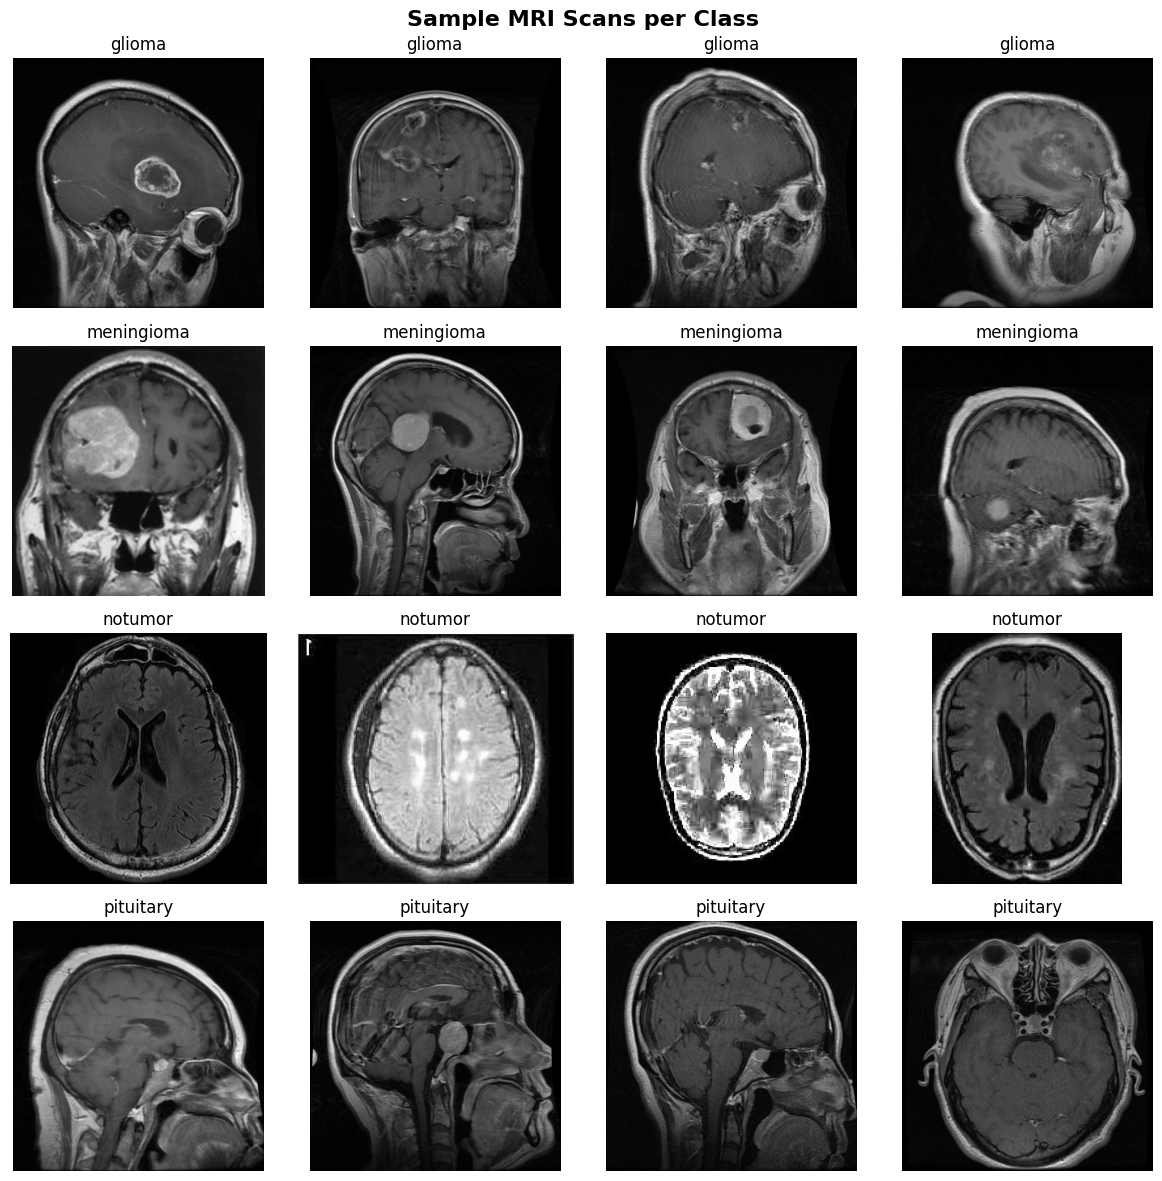

In [3]:
# Visualise sample images from each class 
def show_sample_images(dataset, class_names, n=4):
    # create a grid: rows = number of classes, cols = number of samples per class
    fig, axes = plt.subplots(len(class_names), n, figsize=(n * 3, len(class_names) * 3))
    
    # main title for the entire figure
    fig.suptitle('Sample MRI Scans per Class', fontsize=16, fontweight='bold')

    # dictionary to store indices of images belonging to each class
    class_indices = defaultdict(list)

    # loop through dataset samples and group indices by class label
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    # iterate over each class (row-wise)
    for row, cls in enumerate(range(len(class_names))):
        # randomly pick n samples from current class
        chosen = random.sample(class_indices[cls], n)

        for col, idx in enumerate(chosen):
            # get image file path
            img_path = dataset.samples[idx][0]

            # open image and convert to grayscale
            img = Image.open(img_path).convert('L')

            # display image
            axes[row][col].imshow(img, cmap='gray')
            axes[row][col].axis('off')  # remove axes for cleaner look

            axes[row][col].set_title(class_names[cls])

    plt.tight_layout()  # adjust spacing to avoid overlap
    plt.show()          # render the plot

show_sample_images(train_dataset, CLASS_NAMES)

In [4]:
class MLP(nn.Module):
    """Fully-connected baseline. Flattens the image, losing all spatial info."""

    def __init__(self, input_dim=3 * 128 * 128, num_classes=4):
        super().__init__()  # initialize nn.Module

        # define the full network as a sequence of layers
        self.network = nn.Sequential(
            nn.Flatten(),  # converts (C, H, W) → (C*H*W)

            nn.Linear(input_dim, 512),  # first dense layer
            nn.ReLU(),                 # non-linearity
            nn.Dropout(0.4),           # regularization (prevents overfitting)

            nn.Linear(512, 256),       # second dense layer
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),       # third dense layer
            nn.ReLU(),

            nn.Linear(128, num_classes),  # output layer (logits for 4 classes)
        )

    def forward(self, x):
        return self.network(x)  # pass input through the network


# create model and move it to GPU/CPU
mlp = MLP().to(DEVICE)

# count total trainable parameters
total_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)

print(f'MLP total trainable parameters: {total_params:,}')
print(mlp)  # prints model architecture

MLP total trainable parameters: 25,331,076
MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=49152, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [5]:
class BrainTumorCNN(nn.Module):
    """
    3-block CNN for brain tumour classification.
    Each block: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
    """

    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()

        # Block 1 input: (3, 128, 128) → output: (32, 64, 64)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # extract low-level features
            nn.BatchNorm2d(32), # stabilize training
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1), # deeper feature extraction
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2), # downsample (128 → 64)
            nn.Dropout2d(dropout / 2), # prevent overfitting
        )

        # Block 2 (32, 64, 64) → (64, 32, 32)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2),  # 64 → 32
            nn.Dropout2d(dropout / 2),
        )

        # Block 3 (64, 32, 32) → (128, 16, 16)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2, 2), # 32 → 16
            nn.Dropout2d(dropout / 2),
        )

        #Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),  # compress spatial info to fixed size
            nn.Flatten(),# convert to 1D vector

            nn.Linear(128 * 4 * 4, 256),# dense layer
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(256, num_classes),# final output (logits)
        )

        self.feature_maps = {}

    def forward(self, x):
        x = self.block1(x)  # feature extraction stage 1
        x = self.block2(x)  # deeper features
        x = self.block3(x)  # high-level features
        x = self.classifier(x)  # classification
        return x


# initialize model
cnn = BrainTumorCNN(num_classes=NUM_CLASSES).to(DEVICE)

# count parameters
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)

print(f'CNN total trainable parameters: {total_params:,}')
print(cnn)

CNN total trainable parameters: 813,476
BrainTumorCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
 

In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    
    model.train()  # switch model to training mode (enables dropout, batchnorm updates)

    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        # move data to GPU/CPU
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()   # clear old gradients
        outputs = model(images)      # forward pass
        loss = criterion(outputs, labels)  # compute loss

        loss.backward()# compute gradients
        optimizer.step()   # update weights

        # accumulate loss (scaled by batch size)
        total_loss += loss.item() * images.size(0)

        # get predicted class (highest logit)
        preds = outputs.argmax(dim=1)

        # count correct predictions
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    # return average loss and accuracy
    return total_loss / total, correct / total


@torch.no_grad()  # disables gradient computation (faster + less memory)
def evaluate(model, loader, criterion):
    """Evaluate on a dataloader. Returns (avg_loss, accuracy, all_preds, all_labels)."""
    
    model.eval()  # switch to evaluation mode (no dropout, fixed batchnorm)

    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)      # forward pass only
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        # store predictions for later analysis (confusion matrix, etc.)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, test_loader, epochs=20, lr=1e-3,
                 weight_decay=1e-4, model_name='model'):
    """Full training loop with scheduler. Returns history dict."""

    criterion = nn.CrossEntropyLoss()  # classification loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # learning rate scheduler (smooth cosine decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # store training history
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_acc, best_state = 0.0, None

    # pretty printing header
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8}')
    print('-' * 60)

    for epoch in range(1, epochs + 1):

        # train for one epoch
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)

        # evaluate on validation/test set
        vl_loss, vl_acc, _, _ = evaluate(model, test_loader, criterion)

        scheduler.step()  # update learning rate

        # store metrics
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        # save best model weights
        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # print progress
        print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {vl_loss:>8.4f} | {vl_acc*100:>7.2f}%')

    # restore best model
    model.load_state_dict(best_state)

    print(f'\nBest Validation Accuracy: {best_acc*100:.2f}%')
    return history

## Experiments

### Experiment 1: Baseline MLP

In [7]:
mlp = MLP().to(DEVICE)
mlp_history = run_training(
    mlp, train_loader, test_loader,
    epochs=20, lr=1e-3, model_name='MLP Baseline'
)


  Training: MLP Baseline
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     1.3950 |    43.59% |   1.0927 |   55.62%
     2 |     1.0625 |    53.34% |   1.0189 |   60.12%
     3 |     1.0430 |    52.64% |   1.0103 |   60.75%
     4 |     1.0418 |    54.23% |   0.9928 |   60.38%
     5 |     1.0328 |    52.11% |   1.0017 |   58.25%
     6 |     1.0030 |    54.20% |   0.9376 |   65.69%
     7 |     0.9653 |    54.98% |   0.9330 |   67.12%
     8 |     0.9845 |    55.66% |   0.9137 |   65.25%
     9 |     0.9679 |    56.82% |   0.9449 |   63.00%
    10 |     0.9965 |    53.79% |   0.8893 |   64.62%
    11 |     0.9371 |    56.64% |   0.9289 |   67.69%
    12 |     0.9335 |    57.20% |   0.8935 |   67.31%
    13 |     0.9212 |    57.14% |   0.8966 |   69.06%
    14 |     0.8766 |    61.21% |   0.8850 |   66.38%
    15 |     0.8484 |    63.34% |   0.9044 |   68.19%
    16 |     0.8401 |    63.52% |   0.9144 |   68

### Experiment 2: CNN

In [9]:
cnn = BrainTumorCNN(num_classes=NUM_CLASSES, dropout=0.4).to(DEVICE)
cnn_history = run_training(
    cnn, train_loader, test_loader,
    epochs=20, lr=1e-3, model_name='CNN Default'
)


  Training: CNN Default
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     0.9114 |    61.12% |   0.8712 |   68.19%
     2 |     0.6800 |    72.04% |   0.9041 |   72.25%
     3 |     0.6149 |    74.25% |   0.7814 |   73.06%
     4 |     0.5756 |    76.66% |   0.7444 |   72.12%
     5 |     0.5451 |    77.96% |   0.8137 |   72.19%
     6 |     0.5171 |    78.52% |   0.7561 |   74.94%
     7 |     0.4865 |    80.73% |   0.7480 |   74.75%
     8 |     0.4599 |    81.91% |   0.7143 |   75.75%
     9 |     0.4376 |    83.11% |   0.6949 |   78.44%
    10 |     0.3986 |    84.52% |   0.6903 |   80.00%
    11 |     0.3766 |    85.57% |   0.7448 |   82.31%
    12 |     0.3567 |    86.46% |   0.7147 |   81.88%
    13 |     0.3339 |    87.20% |   0.7237 |   82.75%
    14 |     0.3162 |    88.04% |   0.7034 |   83.31%
    15 |     0.2888 |    88.79% |   0.6972 |   83.50%
    16 |     0.2759 |    89.57% |   0.6609 |   84.

### Experiment 3: CNN with Higher LR

In [10]:
cnn_highLR = BrainTumorCNN(num_classes=NUM_CLASSES, dropout=0.4).to(DEVICE)
cnn_highLR_history = run_training(
    cnn_highLR, train_loader, test_loader,
    epochs=20, lr=3e-3, model_name='CNN LR=3e-3'
)


  Training: CNN LR=3e-3
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     1.1932 |    49.91% |   1.0737 |   58.44%
     2 |     0.8718 |    62.71% |   1.0233 |   64.00%
     3 |     0.7567 |    68.48% |   1.0868 |   66.75%
     4 |     0.7085 |    70.14% |   0.8986 |   67.19%
     5 |     0.6729 |    71.57% |   0.7633 |   69.31%
     6 |     0.6345 |    73.36% |   0.8234 |   70.19%
     7 |     0.6259 |    73.86% |   0.8038 |   71.62%
     8 |     0.6005 |    75.23% |   0.8193 |   68.81%
     9 |     0.5720 |    75.79% |   0.8133 |   72.19%
    10 |     0.5611 |    76.95% |   0.9323 |   72.81%
    11 |     0.5320 |    78.93% |   0.9980 |   74.19%
    12 |     0.5221 |    78.82% |   0.7588 |   73.12%
    13 |     0.4817 |    80.82% |   0.8399 |   75.44%
    14 |     0.4849 |    80.68% |   0.8985 |   74.69%
    15 |     0.4789 |    80.73% |   0.8993 |   75.12%
    16 |     0.4413 |    82.14% |   0.8743 |   76.

### Experiment 4: CNN with Lower Dropout

In [11]:
cnn_lowDrop = BrainTumorCNN(num_classes=NUM_CLASSES, dropout=0.2).to(DEVICE)
cnn_lowDrop_history = run_training(
    cnn_lowDrop, train_loader, test_loader,
    epochs=20, lr=1e-3, model_name='CNN Dropout=0.2'
)


  Training: CNN Dropout=0.2
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
------------------------------------------------------------
     1 |     0.8669 |    63.46% |   0.9215 |   67.12%
     2 |     0.6283 |    74.02% |   0.8708 |   70.69%
     3 |     0.5645 |    77.21% |   0.7227 |   75.81%
     4 |     0.4940 |    80.09% |   0.9973 |   71.88%
     5 |     0.4788 |    80.96% |   0.7472 |   76.88%
     6 |     0.4187 |    83.34% |   0.6658 |   79.94%
     7 |     0.3850 |    84.32% |   0.7314 |   78.81%
     8 |     0.3587 |    85.91% |   0.6252 |   81.75%
     9 |     0.3202 |    87.64% |   0.7114 |   80.25%
    10 |     0.2876 |    88.93% |   0.6712 |   83.56%
    11 |     0.2664 |    90.11% |   0.7351 |   83.56%
    12 |     0.2391 |    90.34% |   0.6257 |   85.62%
    13 |     0.2194 |    91.48% |   0.6839 |   86.88%
    14 |     0.1995 |    92.45% |   0.6859 |   87.81%
    15 |     0.1778 |    93.70% |   0.6445 |   89.81%
    16 |     0.1711 |    93.36% |   0.6327 |  

## Results

### Training Curves

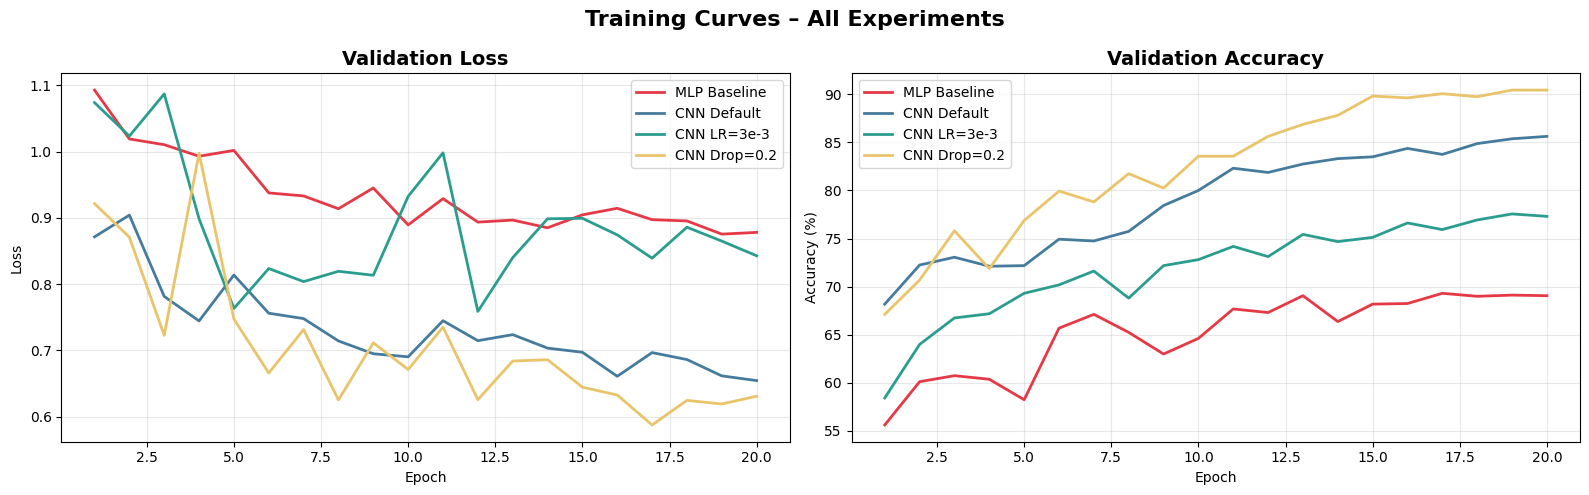

In [12]:
def plot_training_curves(histories: dict):
    """Plot loss and accuracy curves for multiple models side-by-side."""

    # create 2 plots: one for loss, one for accuracy
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # predefined colors for different models
    colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']

    # loop through each model's history
    for (name, hist), color in zip(histories.items(), colors):
        # epochs = [1, 2, ..., N]
        epochs = range(1, len(hist['train_loss']) + 1)

        # plot validation loss
        axes[0].plot(epochs, hist['val_loss'],
                     label=name, color=color, linewidth=2)

        # plot validation accuracy (converted to %)
        axes[1].plot(epochs,
                     [a * 100 for a in hist['val_acc']],
                     label=name, color=color, linewidth=2)

    # titles for both plots
    axes[0].set_title('Validation Loss', fontsize=14, fontweight='bold')
    axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')

    # common formatting for both axes
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    # y-axis labels
    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Accuracy (%)')

    # overall title
    plt.suptitle('Training Curves : All Experiments', fontsize=16, fontweight='bold')

    plt.tight_layout()  # fix spacing
    plt.show()


# dictionary of all experiment histories
all_histories = {
    'MLP Baseline'   : mlp_history,
    'CNN Default'    : cnn_history,
    'CNN LR=3e-3'    : cnn_highLR_history,
    'CNN Drop=0.2'   : cnn_lowDrop_history,
}

# plot everything
plot_training_curves(all_histories)

### Confusion Matrix

CNN Low Droput: Test Set Performance


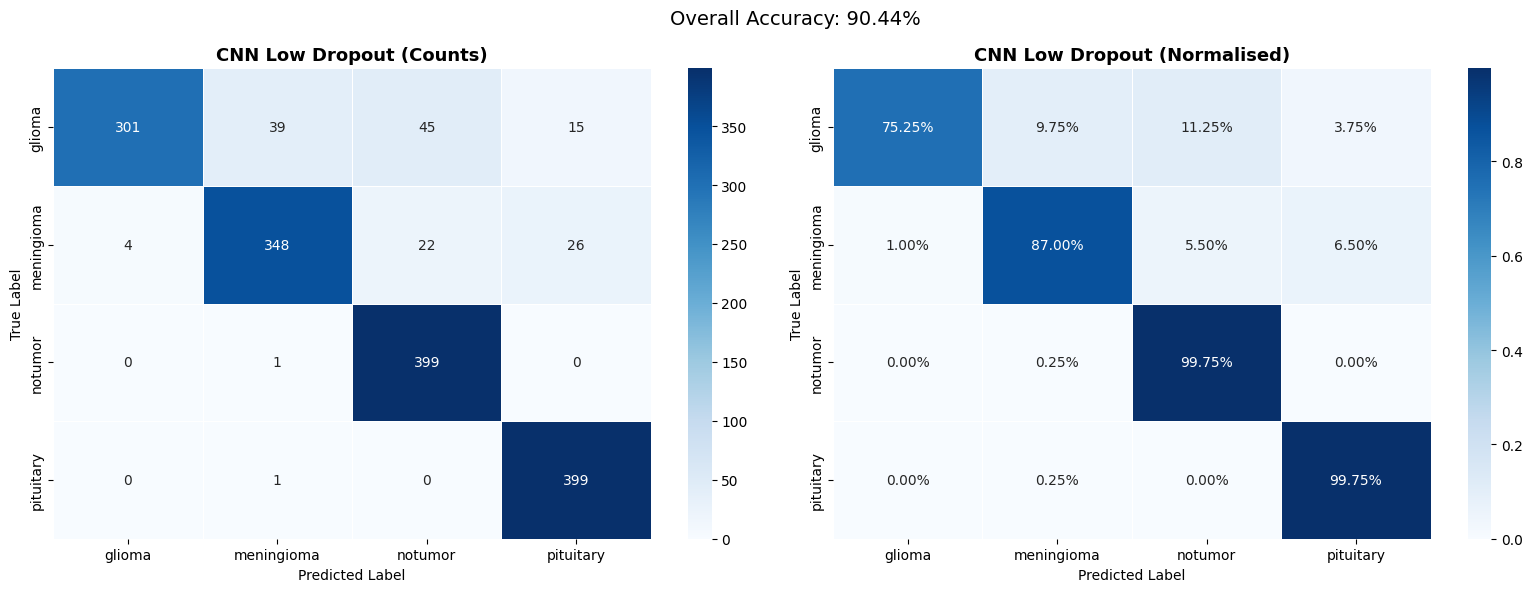


Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.75      0.85       400
  meningioma       0.89      0.87      0.88       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.91      1.00      0.95       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600


MLP Baseline: Test Set Performance


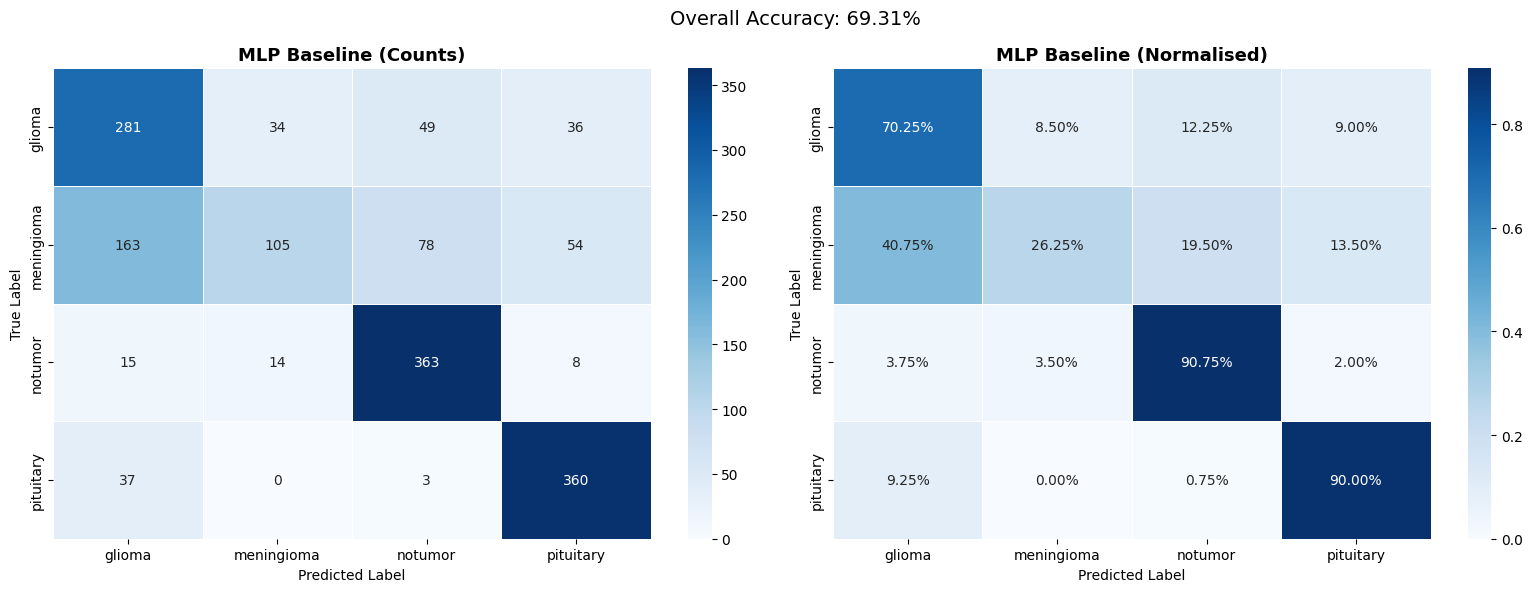


Classification Report:
              precision    recall  f1-score   support

      glioma       0.57      0.70      0.63       400
  meningioma       0.69      0.26      0.38       400
     notumor       0.74      0.91      0.81       400
   pituitary       0.79      0.90      0.84       400

    accuracy                           0.69      1600
   macro avg       0.69      0.69      0.66      1600
weighted avg       0.69      0.69      0.66      1600



In [20]:
def plot_confusion_matrix(model, loader, class_names, title='Confusion Matrix'):
    # use same loss as training (not strictly needed for confusion matrix, but consistent)
    criterion = nn.CrossEntropyLoss()

    # get predictions, labels, and accuracy
    _, acc, preds, labels = evaluate(model, loader, criterion)

    # compute confusion matrix (counts)
    cm = confusion_matrix(labels, preds)

    # normalize per row (each row sums to 1 → per-class accuracy distribution)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # create two plots: raw counts and normalized
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # loop over both matrices (raw + normalized)
    for ax, data, fmt, t in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2%'],  # integer for counts, percentage for normalized
        [f'{title} (Counts)', f'{title} (Normalised)']
    ):
        sns.heatmap(
            data,
            annot=True,              # show numbers inside cells
            fmt=fmt,                # format (int or percentage)
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5,
            ax=ax
        )

        ax.set_title(t, fontsize=13, fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    # overall accuracy at the top
    plt.suptitle(f'Overall Accuracy: {acc*100:.2f}%', fontsize=14)

    plt.tight_layout()
    plt.show()

    # print detailed metrics
    print('\nClassification Report:')
    print(classification_report(labels, preds, target_names=class_names))

    return preds, labels


# Best CNN
print('CNN Low Droput: Test Set Performance')
cnn_preds, cnn_labels = plot_confusion_matrix(
    cnn_lowDrop, test_loader, CLASS_NAMES, title='CNN Low Dropout'
)

# MLP Baseline
print('\nMLP Baseline: Test Set Performance')
mlp_preds, mlp_labels = plot_confusion_matrix(
    mlp, test_loader, CLASS_NAMES, title='MLP Baseline'
)

### Experiment Summary Table

In [22]:
criterion = nn.CrossEntropyLoss()

results = []

# loop through all trained models and their histories
for name, (model, history) in [
    ('MLP Baseline',  (mlp,         mlp_history)),
    ('CNN Default',   (cnn,         cnn_history)),
    ('CNN LR=3e-3',   (cnn_highLR,  cnn_highLR_history)),
    ('CNN Drop=0.2',  (cnn_lowDrop, cnn_lowDrop_history)),
]:

    # evaluate model on test set
    _, acc, _, _ = evaluate(model, test_loader, criterion)

    # best validation accuracy achieved during training
    best_val_acc = max(history['val_acc'])

    # total number of trainable parameters in model
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # store results in structured format
    results.append({
        'Model'         : name,
        'Parameters'    : f'{params:,}',
        'Best Val Acc'  : f'{best_val_acc*100:.2f}%',
        'Final Test Acc': f'{acc*100:.2f}%',
    })

# convert list of dicts into a table
df_results = pd.DataFrame(results)

# print clean table
print(df_results.to_string(index=False))

       Model Parameters Best Val Acc Final Test Acc
MLP Baseline 25,331,076       69.31%         69.31%
 CNN Default    813,476       85.62%         85.62%
 CNN LR=3e-3    813,476       77.56%         77.56%
CNN Drop=0.2    813,476       90.44%         90.44%


### Sample Predictions

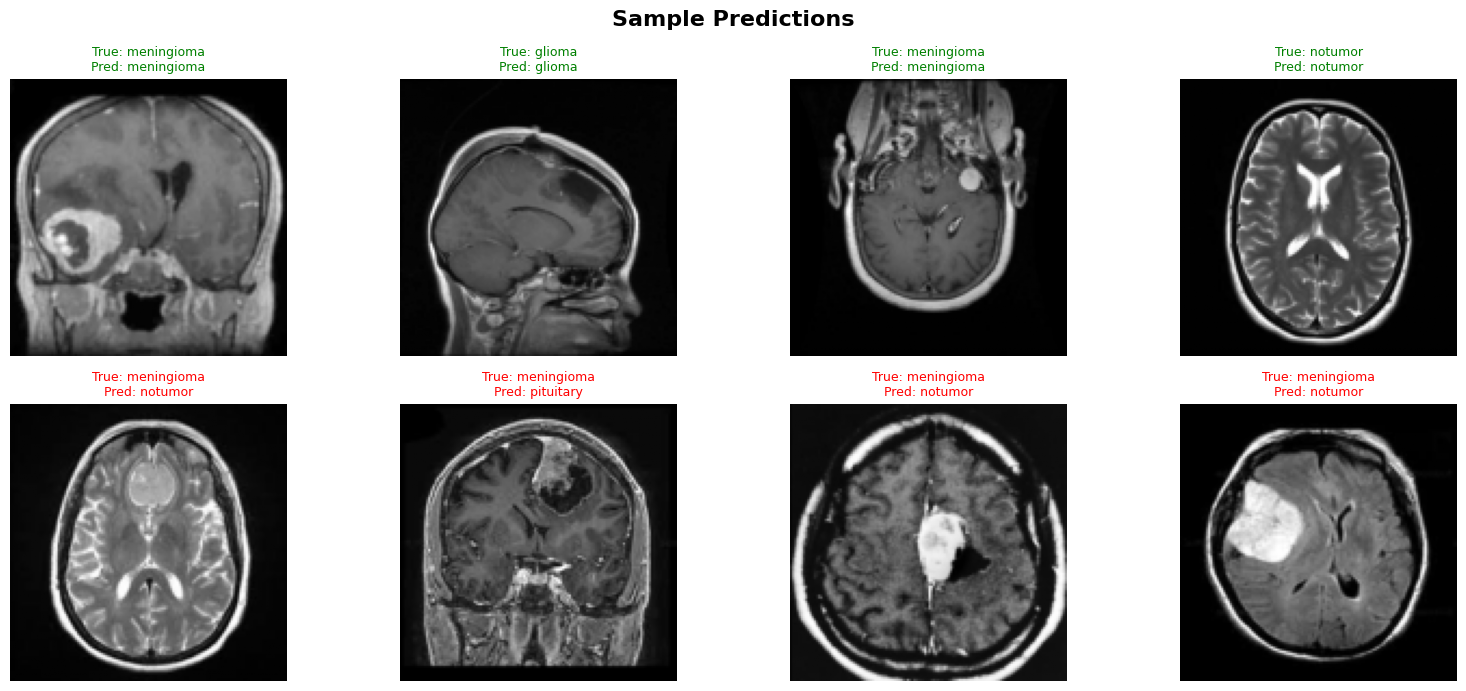

In [21]:
def show_predictions(model, dataset, class_names, n_correct=4, n_wrong=4):
    """Show sample correct and incorrect predictions side by side."""

    model.eval()  # switch to inference mode

    correct_samples, wrong_samples = [], []

    # load data in batches for efficiency
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    with torch.no_grad():  # no gradients needed → faster + memory efficient
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)         # forward pass
            preds = outputs.argmax(dim=1)   # predicted class

            # loop through batch
            for i in range(len(labels)):
                entry = (images[i].cpu(), labels[i].item(), preds[i].item())

                # store correct predictions
                if preds[i] == labels[i] and len(correct_samples) < n_correct:
                    correct_samples.append(entry)

                # store incorrect predictions
                elif preds[i] != labels[i] and len(wrong_samples) < n_wrong:
                    wrong_samples.append(entry)

            # stop early once we have enough samples
            if len(correct_samples) >= n_correct and len(wrong_samples) >= n_wrong:
                break

    # create grid: 2 rows (correct / incorrect)
    fig, axes = plt.subplots(2, max(n_correct, n_wrong), figsize=(16, 7))

    fig.suptitle('Sample Predictions', fontsize=16, fontweight='bold')

    # reverse normalization (0.5 mean, 0.5 std used earlier)
    def _unnorm(tensor):
        return (tensor * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

    # Correct predictions row 
    for col, (img, true, pred) in enumerate(correct_samples):
        axes[0][col].imshow(_unnorm(img)[:, :, 0], cmap='gray')

        axes[0][col].set_title(
            f'True: {class_names[true]}\nPred: {class_names[pred]}',
            color='green',
            fontsize=9
        )

        axes[0][col].axis('off')

    axes[0][0].set_ylabel('✓ Correct', fontsize=12, color='green',
                          rotation=0, labelpad=55, va='center')

    # Wrong predictions row
    for col, (img, true, pred) in enumerate(wrong_samples):
        axes[1][col].imshow(_unnorm(img)[:, :, 0], cmap='gray')

        axes[1][col].set_title(
            f'True: {class_names[true]}\nPred: {class_names[pred]}',
            color='red',
            fontsize=9
        )

        axes[1][col].axis('off')

    axes[1][0].set_ylabel('✗ Incorrect', fontsize=12, color='red',
                          rotation=0, labelpad=55, va='center')

    plt.tight_layout()
    plt.show()


# run visualization on best CNN Model
show_predictions(cnn_lowDrop, test_dataset, CLASS_NAMES)

### Feature Map Visualization

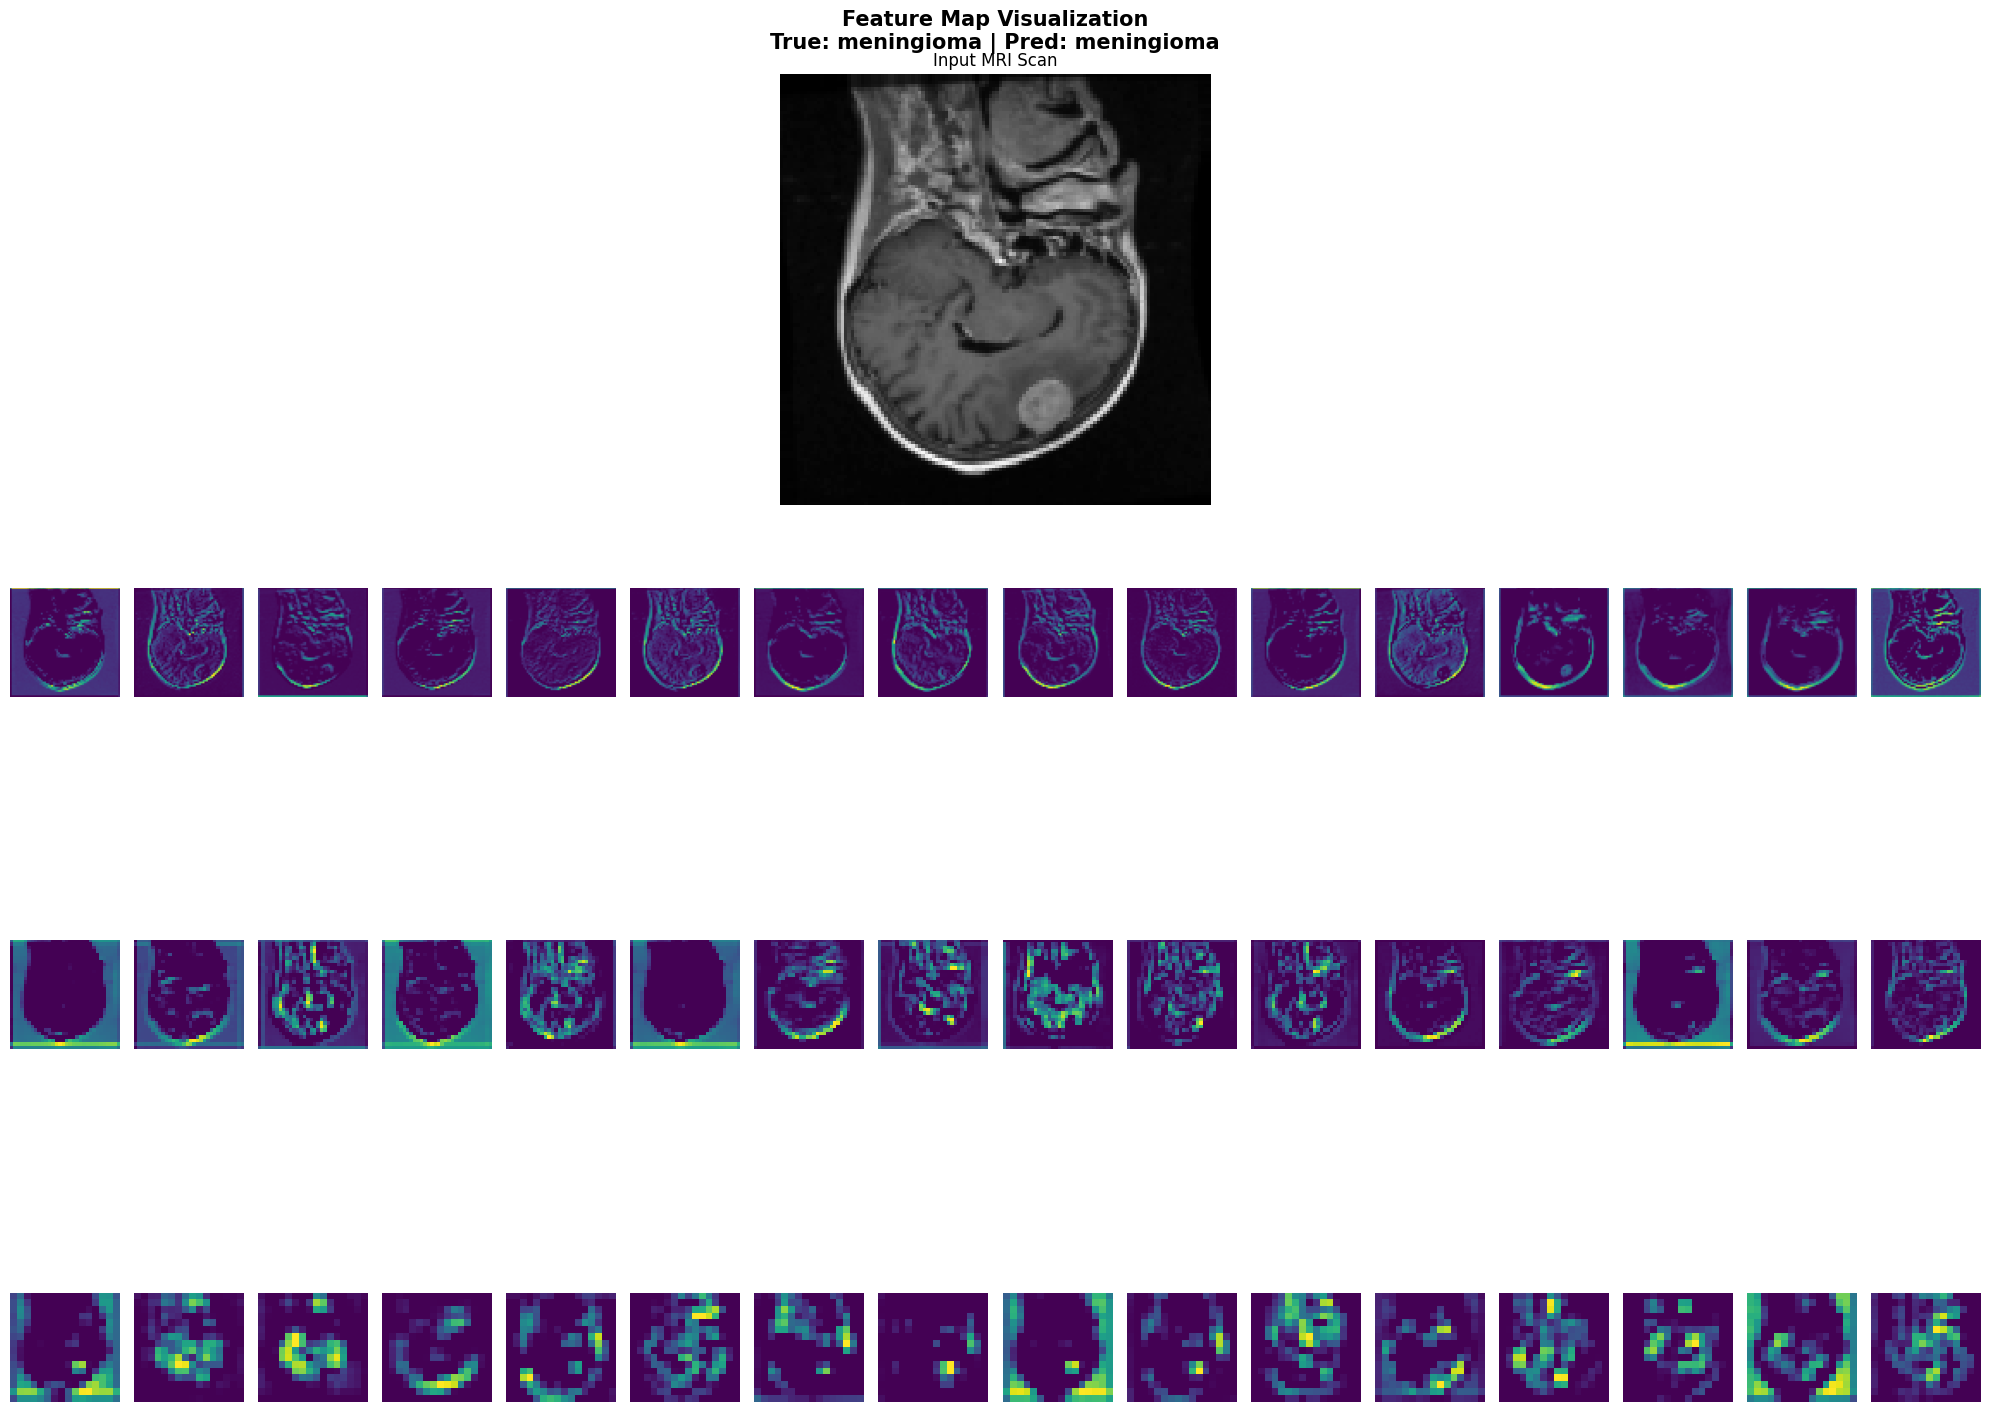

In [23]:
def visualize_feature_maps(model, dataset, class_names, n_filters=16):
    """
    Forward one image through the model and display:
    - Original MRI scan
    - Feature maps from early, mid, and deep CNN layers
    """

    model.eval()  # inference mode

    # pick a random image from dataset
    img, label = dataset[random.randint(0, len(dataset) - 1)]

    # add batch dimension: (3,128,128) → (1,3,128,128)
    x = img.unsqueeze(0).to(DEVICE)

    #  store activations from hooks 
    activations = {}

    def make_hook(name):
        def hook(module, input, output):
            activations[name] = output.detach().cpu()
        return hook

    # register hooks on CNN blocks
    h1 = model.block1.register_forward_hook(make_hook('block1'))
    h2 = model.block2.register_forward_hook(make_hook('block2'))
    h3 = model.block3.register_forward_hook(make_hook('block3'))

    # forward pass (hooks automatically capture outputs)
    with torch.no_grad():
        output = model(x)
        pred = output.argmax(dim=1).item()

    # remove hooks (important cleanup step)
    h1.remove(); h2.remove(); h3.remove()

    #Visualization setup
    fig = plt.figure(figsize=(20, 16))

    fig.suptitle(
        f'Feature Map Visualization\nTrue: {class_names[label]} | Pred: {class_names[pred]}',
        fontsize=15, fontweight='bold'
    )

    #original image
    ax0 = fig.add_subplot(4, 1, 1)

    # reverse normalization
    orig = (img * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()[:, :, 0]

    ax0.imshow(orig, cmap='gray')
    ax0.set_title('Input MRI Scan')
    ax0.axis('off')

    # feature maps visualization
    for row_idx, (block_name, title) in enumerate([
        ('block1', 'Block 1 - Early Features (Edges & Boundaries)'),
        ('block2', 'Block 2 - Mid Features (Textures & Regions)'),
        ('block3', 'Block 3 - Deep Features (High-level Structures)'),
    ], start=1):

        # feature maps: (C, H, W)
        fmaps = activations[block_name][0]

        # number of filters to show
        n = min(n_filters, fmaps.shape[0])

        # grid layout
        gs = gridspec.GridSpec(4, n_filters, figure=fig)

        for col in range(n):
            ax = fig.add_subplot(gs[row_idx, col])

            # individual feature map
            fm = fmaps[col].numpy()

            ax.imshow(fm, cmap='viridis')
            ax.axis('off')

            # label only first column
            if col == 0:
                ax.set_ylabel(title, fontsize=9, rotation=90, labelpad=5)

    plt.tight_layout()
    plt.show()


# run visualization
visualize_feature_maps(cnn_lowDrop, test_dataset, CLASS_NAMES, n_filters=16)

## Analysis & Discussion

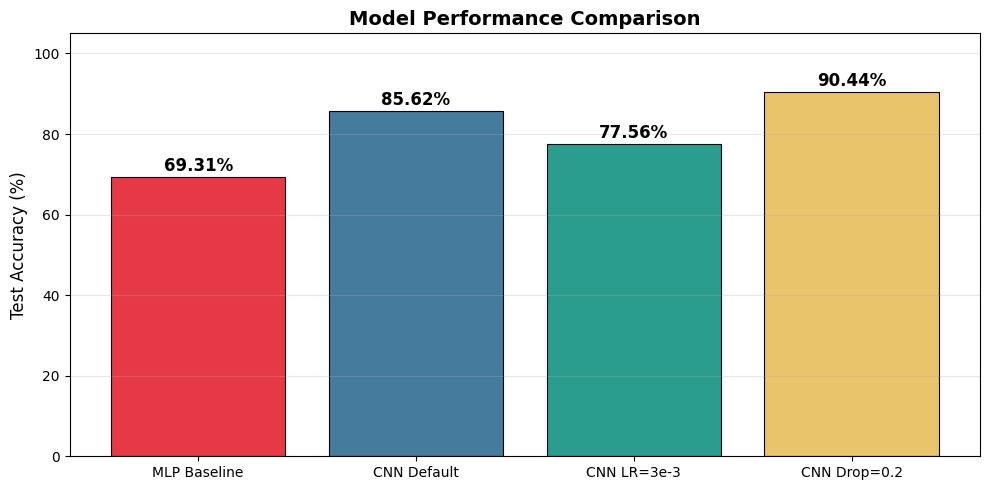

In [25]:
# Final side-by-side accuracy bar chart 
criterion = nn.CrossEntropyLoss()
model_names, accuracies = [], []

for name, model in [
    ('MLP Baseline', mlp),
    ('CNN Default',  cnn),
    ('CNN LR=3e-3',  cnn_highLR),
    ('CNN Drop=0.2', cnn_lowDrop),
]:
    _, acc, _, _ = evaluate(model, test_loader, criterion)
    model_names.append(name)
    accuracies.append(acc * 100)

colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### CNN vs MLP

The CNN significantly outperforms the MLP on this brain tumor classification task.  
The MLP, despite having **~25.3 million parameters**, achieves only **69.31% test accuracy**, whereas the best CNN variant achieves **90.44% test accuracy with only ~0.81 million parameters**.

This clearly shows that **model architecture matters more than parameter count**.

The MLP flattens the 128×128 MRI image into a 49,152-dimensional vector, destroying spatial relationships between pixels.  
In contrast, CNNs preserve spatial structure through convolutional filters, allowing them to learn medically meaningful features such as tumor edges, intensity variations, and shape irregularities.


### Role of Convolution

Feature map visualizations confirm hierarchical feature learning:

- **Block 1 (Early layers):** edges, boundaries, skull structure  
- **Block 2 (Mid layers):** textures and localized tumor regions  
- **Block 3 (Deep layers):** high-level tumor representations  

This demonstrates how CNNs progressively transform raw pixels into abstract diagnostic features.


### Role of Pooling and Regularization

Max Pooling provides **translation invariance**, ensuring tumors are detected regardless of their position in the image. It also reduces spatial dimensions, encouraging the network to learn compact representations.

Dropout plays an important role in reducing overfitting:

- CNN (dropout 0.4): **85.62% accuracy**
- CNN (dropout 0.2): **90.44% accuracy (best model)**

This shows that moderate dropout improves generalization for this dataset.

Batch Normalization was also critical for stable and faster convergence across all CNN variants.

### Hyperparameter Observations

- Higher learning rate (**3e-3**) led to unstable training and lower performance (**77.56% accuracy**)  
- Default learning rate (**1e-3 with cosine annealing**) provided smoother convergence  
- Reduced dropout improved performance, indicating slight underfitting in stronger regularization settings  


### Class-wise Performance

From the classification report:

- **Pituitary tumor:** highest performance (~95% F1-score)  
- **Notumor:** near-perfect recall (1.00), highly separable class  
- **Glioma:** lower recall (~0.75), often misclassified  
- **Meningioma:** relatively harder class  

The most common confusion occurs between **Glioma and Meningioma**, which is expected due to their similar visual appearance in single-sequence MRI scans.


## Conclusion

### CNN vs MLP

CNNs significantly outperform MLPs in medical image classification tasks.  
The best CNN achieves **90.44% accuracy**, while the MLP reaches only **69.31%**, despite having **~30× more parameters**.

This confirms that preserving spatial structure is essential for image-based learning tasks.


### Importance of Feature Learning

CNNs learn hierarchical features:

- Early layers → edges and boundaries  
- Middle layers → textures and regions  
- Deep layers → class-specific tumor structures  

This makes CNNs highly effective for medical imaging applications.


### Regularization and Generalization

Dropout and Batch Normalization significantly improved generalization.  
The best performance was achieved using **moderate dropout (0.2)**, showing that excessive regularization can limit learning capacity.

### Hyperparameter Sensitivity

The model is sensitive to learning rate and dropout settings.  
A higher learning rate reduced performance, while the default configuration provided stable optimization.

### Medical Imaging Limitations

Misclassification between **Glioma and Meningioma** highlights limitations of single-modality MRI inputs.
Future improvements may include:
- Multi-modal MRI (T1, T2, FLAIR)  
- Transfer learning from pretrained medical models  
- Attention-based architectures (Vision Transformers)  